# Contraejemplos → π_L → 0.9307

**Sesión con Francisco: martes 22-sep, 19:00 Praga. Guion de 10 minutos.**
Recorrido principal: **§5 → §7 → §8 → §10**. §11 contiene el cierre de tareas
y los mapas para la discusión. §1 y el notebook 27 quedan como apoyo.

q = P(sano), p = P(infectado), R = número de infectados. El recorrido principal
usa posterior-zero, incluida la primera tabla de §5. El apéndice histórico
de costos que sigue a esa tabla conserva la variante estricta.

Resultados revisados el 21-sep. Guion oral y pendientes precisos en
`docs/notes/2026-09-22-guion-francisco-hector.md`.


In [1]:
from pathlib import Path
import sys, json
from fractions import Fraction as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'augmented' / 'bm17_toy_solver.py').exists())
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results' / 'precio_laminar_2026-09-21'
datos = json.loads((RESULTS / 'resultados.json').read_text())
tabla = pd.read_csv(RESULTS / 'comparacion.csv')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Q = 0.30
P = 1 - Q

AZUL = "#2563eb"
AMBAR = "#d97706"
VERDE = "#059669"
GRIS = "#64748b"
TINTA = "#172033"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

print(f"q = {Q:.2f} sana | p = {P:.2f} infectada")

q = 0.30 sana | p = 0.70 infectada


## 1. Los dos extremos: S0 y V

Para un pool fresco homogéneo de tamaño k:

$$
S_0(k)=q^k k.
$$

S0 pregunta cuánto se cobra **con esta prueba**. Solo paga si las k personas
están sanas, es decir, si r = 0.

El score de presupuesto mágico es:

$$
V(T)=\sum_{i\in T}u_i\,P(i\text{ sana}\mid h).
$$

V pregunta cuánto podría extraerse si todas las pruebas de seguimiento fueran
gratis. Para un pool fresco con utilidad unitaria, V(k)=qk.

Así aparecen los dos extremos

- S0 evita pools grandes.
- V prefiere pools grandes, aunque después no sepa cosecharlos.

In [2]:
ks = np.arange(1, 7)
tabla_scores = pd.DataFrame({
    "tamaño k": ks,
    "S0: cobro inmediato": (Q ** ks) * ks,
    "V: seguimiento gratis": Q * ks,
})

assert tabla_scores.loc[0, "S0: cobro inmediato"] == 0.3
assert abs(tabla_scores.loc[1, "S0: cobro inmediato"] - 0.18) < 1e-12
assert abs(tabla_scores.loc[1, "V: seguimiento gratis"] - 0.6) < 1e-12
tabla_scores

,tamaño k,S0: cobro inmediato,V: seguimiento gratis
0,1,0.300000,0.3
1,2,0.180000,0.6
2,3,0.081000,0.9
3,4,0.032400,1.2
4,5,0.012150,1.5
5,6,0.004374,1.8


In [3]:
# FIGURA 1 DE 2
fig, ax = plt.subplots(figsize=(7.2, 3.7))
ax.plot(ks, tabla_scores["S0: cobro inmediato"], marker="o", lw=2.4,
        color=AMBAR, label="S0: cobrar ahora")
ax.plot(ks, tabla_scores["V: seguimiento gratis"], marker="o", lw=2.4,
        color=AZUL, label="V: extraer con seguimiento gratis")
ax.set_xlabel("Tamaño del pool k")
ax.set_ylabel("Score")
ax.set_xticks(ks)
ax.set_title("S0 se encoge; V crece con el tamaño del pool")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

/var/folders/zn/lnx_6ksj0r1b93bw0d12m0mm0000gn/T/ipykernel_18979/3242483370.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


S0 nunca da el primer paso grande en el régimen
q < 1/2. V sí da ese paso, pero lo hace porque "cree" que el trabajo posterior
es gratis.

## 5. El contraejemplo: utilidad existente frente a utilidad cobrable

Cuatro personas con priors independientes, q=0.3 y utilidad 1 cada una.
AB ya fue probado y dio R=1; C y D siguen sin probar. Queda una sola prueba.
El score antiguo V suma la utilidad sana esperada dentro del pool elegido.


**Comparación vigente: posterior-zero y una prueba restante.**

| Acción | Score antiguo V | Utilidad esperada que cobra esa prueba |
|---|---:|---:|
| Probar A | 0.5 | **1**: acredita A o B según el resultado |
| Probar CD | **0.6** | 0.18: solo R(CD)=0 permite acreditar a ambos |
| Repetir AB | 1 | 0: no cambia lo que sabemos |

El solver actual excluye repetir AB. **Incluso al excluirlo, V prefiere CD
a A, aunque A cobra más.** El problema persiste entre acciones informativas:
contar utilidad sana existente no mide cuánto podemos cobrar con el presupuesto.

**Frase oral:** «Queríamos valorar la exploración; este ejemplo mostró que
el score también debe reconocer la utilidad que realmente puede extraerse».


**Apoyo histórico de costos — fuera del recorrido de diez minutos.**

La tabla y figura siguientes conservan la acreditación estricta y los costos
históricos 1, 1.63 y 2.5. Bajo esa convención el cobro esperado de probar A es
0.5. La comparación posterior-zero para presentar hoy es la tabla anterior.


In [4]:
acciones = pd.DataFrame({
    "acción": ["Reentrar A", "Par virgen CD", "Retest AB"],
    "V": [0.5, 0.6, 1.0],
    "C total": [1.0, 1.63, 2.5],
    "realizable con 1 prueba": [0.5, 0.18, 0.0],
})
acciones["V/C"] = acciones["V"] / acciones["C total"]

assert acciones.loc[acciones["V"].idxmax(), "acción"] == "Retest AB"
assert acciones.loc[acciones["V/C"].idxmax(), "acción"] == "Reentrar A"
assert acciones.loc[acciones["realizable con 1 prueba"].idxmax(), "acción"] == "Reentrar A"

acciones[["acción", "V", "C total", "V/C", "realizable con 1 prueba"]]

,acción,V,C total,V/C,realizable con 1 prueba
0,Reentrar A,0.5,1.00,0.500000,0.50
1,Par virgen CD,0.6,1.63,0.368098,0.18
2,Retest AB,1.0,2.50,0.400000,0.00


In [5]:
# FIGURA 2 DE 2
criterios = [
    ("V", "V: localiza salud", AZUL),
    ("realizable con 1 prueba", "Cobro realizable ahora", VERDE),
    ("V/C", "V/C: valor por trabajo", AMBAR),
]

fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.7), sharey=True)
for ax, (col, titulo, color) in zip(axes, criterios):
    vals = acciones[col].to_numpy()
    bars = ax.bar(acciones["acción"], vals, color=color, alpha=0.88)
    ax.set_title(titulo, fontsize=10.5)
    ax.tick_params(axis="x", rotation=28)
    ax.grid(axis="y", alpha=0.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.025, f"{val:.2f}",
                ha="center", va="bottom", fontsize=9)

axes[0].set_ylabel("Valor del criterio")
axes[0].set_ylim(0, 1.12)
fig.suptitle("El ranking se invierte cuando cobrar deja de ser gratis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

/var/folders/zn/lnx_6ksj0r1b93bw0d12m0mm0000gn/T/ipykernel_18979/2823152781.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


**Lectura de la figura 2.**

- V elige el retest porque ve una unidad sana atrapada en AB.
- El cobro realizable elige A porque es la única acción que puede acreditar
  esa utilidad con una prueba.
- V/C también elige A: penaliza el trabajo que V había fingido gratuito.



## Del contraejemplo a valor/costo

$$V/C^\alpha.$$

En la tabla histórica, retest y reentrada empatan en
$\alpha=\ln 2/\ln 2.5\approx0.756$. Este umbral compara scores antes del filtro
por presupuesto. La malla de experimentos no encontró un α que dominara en
todos los regímenes. La reparación de un ejemplo no demuestra una garantía.

**Transición oral:** «El costo ayuda a ordenar este caso. Después preguntamos
si las reglas de planificación también sobreviven a poblaciones heterogéneas».

## 7. Una instancia donde falla la batería de cuatro

Seis personas, B=3, G=4, posterior-zero. Probabilidades de infección
(0.9, 0.825, 0.875, 0.8, 0.95, 0.85), utilidades (2, 1, 1, 1, 4, 2).

π_M, π_C y π_R obtienen 0.700000; C3 obtiene 0.69904125. Frente al óptimo
laminar 1.0645140625, sus ratios son 0.657577 y 0.656676, respectivamente.
Es un contraejemplo para esta batería concreta, no para todas las heurísticas.

El menú compara **primera acción + continuación óptima**. Su Q no es el valor
de ejecutar una heurística completa. Después veremos el árbol que logra el óptimo.


In [6]:
from augmented.bm17_toy_solver import SolverLaminar
p_ce = dict(enumerate(map(F, ['.9', '.825', '.875', '.8', '.95', '.85'])))
u_ce = dict(enumerate(map(F, [2, 1, 1, 1, 4, 2])))
sol = SolverLaminar(p_ce, u_ce, 4, 'posterior_zero')
U0 = frozenset(p_ce)
OPT = float(sol.V(U0, (), 3))
NOM = 'ABCDEF'
menu = sorted(((float(sol._q_accion(U0, (), 3, a)),
                ''.join(NOM[i] for i in a[1]))
               for a in sol._acciones(U0, ())), reverse=True)
assert abs(OPT - 1.0645140625) < 1e-12 and menu[0][1] == 'AEF'
assert {s for _, s in menu[-6:]} == set('ABCDEF')
seleccion = {s for _, s in menu[:5]} | set(NOM) | {'ADEF'}
vista = [(v, s) for v, s in menu if s in seleccion]
fig, ax = plt.subplots(figsize=(9.3, 5.7))
labels, colors = [], []
for _, s in vista:
    label = s
    if s == 'AEF': label += '  óptimo laminar'
    if s == 'F': label += '  primera acción de π_M, π_C, π_R'
    if s == 'ADEF': label += '  primera acción de C3 y π_L (λ=.001)'
    labels.append(label)
    colors.append(AZUL if s == 'AEF' else VERDE if s == 'ADEF' else AMBAR if s == 'F' else '#94a3b8')
bars = ax.barh(labels, [v for v, _ in vista], color=colors)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=9)
ax.invert_yaxis(); ax.set_xlim(0, 1.18)
ax.set_xlabel('Utilidad esperada con continuación óptima después de esa acción')
ax.set_title('Raíz: cinco mejores opciones, ADEF y seis individuales (de 56)')
fig.tight_layout()
fig.savefig(RESULTS / 'menu_seis_personas.png', bbox_inches='tight')
plt.show()


/var/folders/zn/lnx_6ksj0r1b93bw0d12m0mm0000gn/T/ipykernel_18979/6835593.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


**Lectura del menú.** El óptimo abre AEF. Las tres políticas del companion
empiezan por F. C3 y π_L empiezan por ADEF, pero toman continuaciones distintas
y obtienen valores distintos. No atribuir a las cuatro heurísticas la misma
primera acción. El gráfico muestra una selección del menú de 56 acciones.


el arbol de la POLITICA optima: 35 nodos — extraido de un problema con 1786 estados distintos (estados de la recursion laminar)


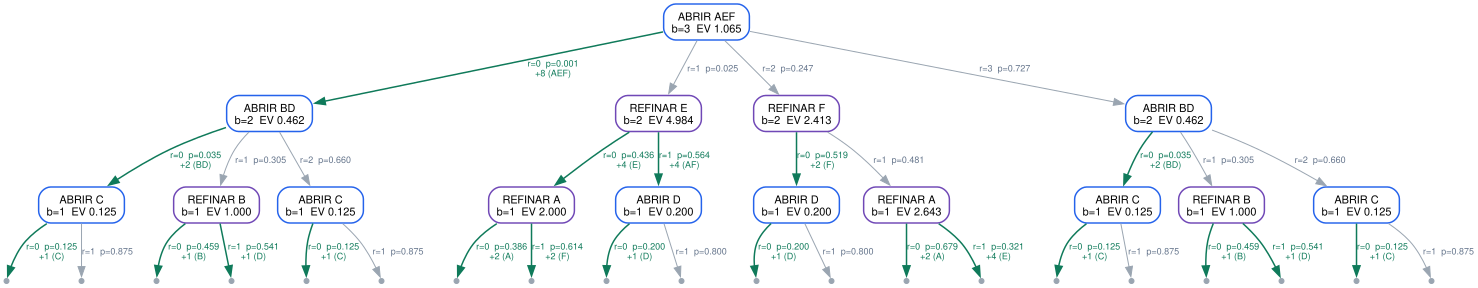

In [7]:
import graphviz

g = graphviz.Digraph(format='svg')
g.attr(rankdir='TB', fontname='Helvetica')
g.attr('node', fontname='Helvetica', fontsize='11')
g.attr('edge', fontname='Helvetica', fontsize='9')
cont = [0]

def dibuja(U, atomos, b):
    U, atomos = sol._canoniza(U, atomos)
    v = float(sol.V(U, atomos, b))
    acc = sol.argmax.get((U, atomos, b))
    yo = f'n{cont[0]}'; cont[0] += 1
    if acc is None or b == 0:
        g.node(yo, '', shape='point', width='0.07', color='#9aa5b1')
        return yo
    verbo = 'ABRIR' if acc[0] == 'open' else 'REFINAR'
    pool = acc[1] if acc[0] == 'open' else acc[2]
    etq = f"{verbo} {''.join(NOM[i] for i in pool)}\nb={b}  EV {v:.3f}"
    g.node(yo, etq, shape='box', style='rounded',
           color=AZUL if verbo == 'ABRIR' else '#7048b6', penwidth='1.5')
    if acc[0] == 'open':
        S = acc[1]; zs = sol._z(S)
        ramas = []
        for s_, prob in enumerate(zs):
            if prob == 0: continue
            rew, nuevos = sol._pieza(S, s_, probado=True)
            ramas.append((s_, float(prob), float(rew),
                          ''.join(NOM[i] for i in S) if s_ == 0 else '',
                          (U - set(S), tuple(sorted(atomos + nuevos)))))
    else:
        _, (A, r), S = acc
        resto = tuple(sorted(set(A) - set(S)))
        zS, zR, zA = sol._z(S), sol._z(resto), sol._z(A)
        otros = tuple(a for a in atomos if a != (A, r))
        ramas = []
        for s_ in range(len(zS)):
            if not (0 <= r - s_ < len(zR)): continue
            prob = zS[s_] * zR[r - s_] / zA[r]
            if prob == 0: continue
            rS, nS = sol._pieza(S, s_, probado=True)
            rR, nR = sol._pieza(resto, r - s_, probado=False)
            acred = (''.join(NOM[i] for i in S) if s_ == 0 else '') + \
                    (''.join(NOM[i] for i in resto) if r - s_ == 0 else '')
            ramas.append((s_, float(prob), float(rS + rR), acred,
                          (U, tuple(sorted(otros + nS + nR)))))
    for s_, prob, rew, acred, (U2, at2) in ramas:
        hijo = dibuja(U2, at2, b - 1)
        etqr = f'r={s_}  p={prob:.3f}'
        if rew > 0:
            g.edge(yo, hijo, label=etqr + f'\n+{rew:.0f} ({acred})',
                   color='#0f7a5a', fontcolor='#0f7a5a', penwidth='1.5')
        else:
            g.edge(yo, hijo, label=etqr, color='#9aa5b1', fontcolor=GRIS)
    return yo

dibuja(U0, (), 3)
print(f'el arbol de la POLITICA optima: {cont[0]} nodos — extraido de un '
      f'problema con {len(sol.memo)} estados distintos '
      f'(estados de la recursion laminar)')
g

**Lectura del árbol.** AEF sale completamente sano con probabilidad
0.00075. Su interés está en las continuaciones condicionadas al conteo.

Tras R(AEF)=1, probar E cobra **4 inmediatamente en ambas ramas**: si E está
sana, aporta u_E=4; si está infectada, A y F quedan sanas por deducción y
aportan 2+2. Todavía puede quedar utilidad adicional de la última prueba.

Tras R(AEF)=3, no se refina un grupo ya resuelto: se cambia de grupo.
**Pregunta:** ¿qué compra la prueba inicial además de la posibilidad de cobro inmediato?


## 8. π_L y las dos referencias

π_L usa utilidad esperada menos λ por prueba esperada, con posibilidad de
abandonar un plan local. Aquí λ=0.001, horizonte=3 y no-parálisis activada.
Su valor 1.026265 equivale a 96.41% del óptimo **laminar** y 92.42% del **general**.

La corrección del cobro del complemento en π_M se verificó por enumeración.
Los valores de las tres políticas de densidad en esta instancia no cambiaron.

$$I_\lambda(C)=\sup_{\pi\text{ local}}\mathbb E[U_{\mathrm{cobrada}}-\lambda T].$$

**π** es la regla que decide qué probar después de cada resultado. **λ** pone
precio a cada prueba efectivamente consumida; abandonar localmente vale cero.
En esta implementación, el horizonte local es min(b, 3) y se replanifica.
Si ningún proyecto supera el precio, no-parálisis elige el mejor cobro inmediato.


In [8]:
politicas = pd.DataFrame(datos['policy_six_person'])
display(politicas[['policy', 'value', 'ratio_laminar', 'ratio_general']].round(6))
display(pd.DataFrame(datos['lambda_sensitivity'])[
    ['lambda_value', 'value', 'ratio_laminar', 'ratio_general']].round(6))

,policy,value,ratio_laminar,ratio_general
0,π_M,0.700000,0.657577,0.630367
1,π_C,0.700000,0.657577,0.630367
2,π_R,0.700000,0.657577,0.630367
3,C3,0.699041,0.656676,0.629504
4,π_L,1.026265,0.964069,0.924177


,lambda_value,value,ratio_laminar,ratio_general
0,0.001,1.026265,0.964069,0.924177
1,0.100,1.026265,0.964069,0.924177
2,0.500,0.700000,0.657577,0.630367
3,1.000,0.700000,0.657577,0.630367
4,2.000,0.700000,0.657577,0.630367


## 9. Lo que este ejemplo permite concluir

- Las cuatro reglas estudiadas pueden perder bastante frente al óptimo laminar.
- π_L mejora este caso con los parámetros declarados. No hay garantía general derivada de él.
- El óptimo general vale 1.1104640625; exigir laminaridad conserva aquí 95.8621%.

**Cierre oral:** «Necesitamos distinguir la calidad de la heurística del costo
de la restricción laminar. Ahora podemos medir ambos en ejemplos pequeños».

Abrir [notebook 27](27_precio_laminar_y_repaso.ipynb) para ver exactamente dónde
ayudan los cruces. El caso de cuatro personas es el más sencillo para explicarlo.

## 10. El 0.9307 y por qué λ es parte de la política

La candidata tiene n=7, B=3, G=4: tres personas casi seguras, tres premios
muy grandes con infección 0.975 y una persona intermedia. Contra el mismo
óptimo laminar del harness histórico, **6.226133**, π_L alcanza **0.930703**
con **λ=1.238469**, horizonte 3 y no-parálisis.

La rejilla se calcula a partir del prior y las utilidades. Se elige λ por el
valor esperado de la política, antes de jugar. OPT sirve después para medir
la razón; no interviene en esa selección.

**Alcance de la verificación de hoy:** esta candidata y esta rejilla. La nota
del 2-sep resume una búsqueda de unas 7,000 instancias; no se reevaluó aquí toda
esa batería con una especificación uniforme. 0.9307 es evidencia empírica,
no una garantía del 93% para cualquier instancia.


In [9]:
from hashlib import sha256
c093 = ROOT/'results/verificacion_constante_093.csv'
meta093 = json.loads(c093.with_suffix('.csv.meta.json').read_text())
for p, digest in meta093['params']['source_sha256'].items():
    assert sha256((ROOT/p).read_bytes()).hexdigest() == digest, f'Regenerar: {p}'
t093 = pd.read_csv(c093)
best093 = t093.loc[t093.groupby('policy')['value'].idxmax()]
display(best093[['policy','lambda_value','value','opt_laminar','ratio']].round(6))
curve = t093[t093.policy=='pi_L'].sort_values('lambda_value')
fig, ax = plt.subplots(figsize=(9.5, 4.1))
ax.semilogx(curve.lambda_value, curve.ratio, 'o-', color='#2563eb')
winner = curve.loc[curve.ratio.idxmax()]
ax.annotate(f"λ={winner.lambda_value:.6f}\nratio={winner.ratio:.6f}",
            (winner.lambda_value,winner.ratio), xytext=(-125,-10),
            textcoords='offset points', arrowprops={'arrowstyle':'->'})
ax.set(xlabel='λ: precio por prueba', ylabel='Valor de π_L / óptimo laminar',
       title='La rejilla debe encontrar la ventana de λ que permite explorar', ylim=(.75,.97))
ax.grid(alpha=.2);fig.tight_layout();fig.savefig(ROOT/'results/constante_093_lambda.png',dpi=150)
plt.show()


,policy,lambda_value,value,opt_laminar,ratio
3,C3,NaN,4.000761,6.226133,0.642576
1,pi_C,NaN,4.900117,6.226133,0.787024
15,pi_L,1.238469,5.794681,6.226133,0.930703
0,pi_M,NaN,4.900117,6.226133,0.787024
2,pi_R,NaN,4.900117,6.226133,0.787024


/var/folders/zn/lnx_6ksj0r1b93bw0d12m0mm0000gn/T/ipykernel_18979/4011467781.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 11. Cierre verificable y preguntas para Francisco

- **BM17:** 296 comparaciones exactas con enumeración de perfiles e historial;
  diferencia cero. Matriz local declarada: 8 anclas, 240 estados heterogéneos,
  48 raíces homogéneas; incluye ambas convenciones en los dos primeros grupos.
- **Ancla G0:** k=B−⌈log₂G⌉=3. 0.914742 es una cota inferior realizable.
- **Mapa 1:** 665/665 casos prefieren estrictamente empezar con un grupo;
  población n=B·G, q=.05,.10,…,.95, G=2,3,4,5,8, B=2,…,8.
- **Mapa 3:** la frontera G=8, B=6, n=24 sí se resolvió. El ancla G=16,
  B=7, n=48 alcanzó 2.5 millones de estados sin certificar OPT.

Bellman aquí optimiza dentro de la clase **laminar por trayectoria**; el
notebook 27 compara esa clase con acciones generales en poblaciones pequeñas.


,case,n,G,B,cota_cbs,cbs_stop,optimo,status
0,ancla,48,16,7,0.914742,0.939440,NaN,state_limit
1,frontera,24,8,6,0.708011,0.727127,0.865394,exact_float64
2,ancla_acciones_G8,48,8,7,0.806289,0.828058,1.123283,exact_float64


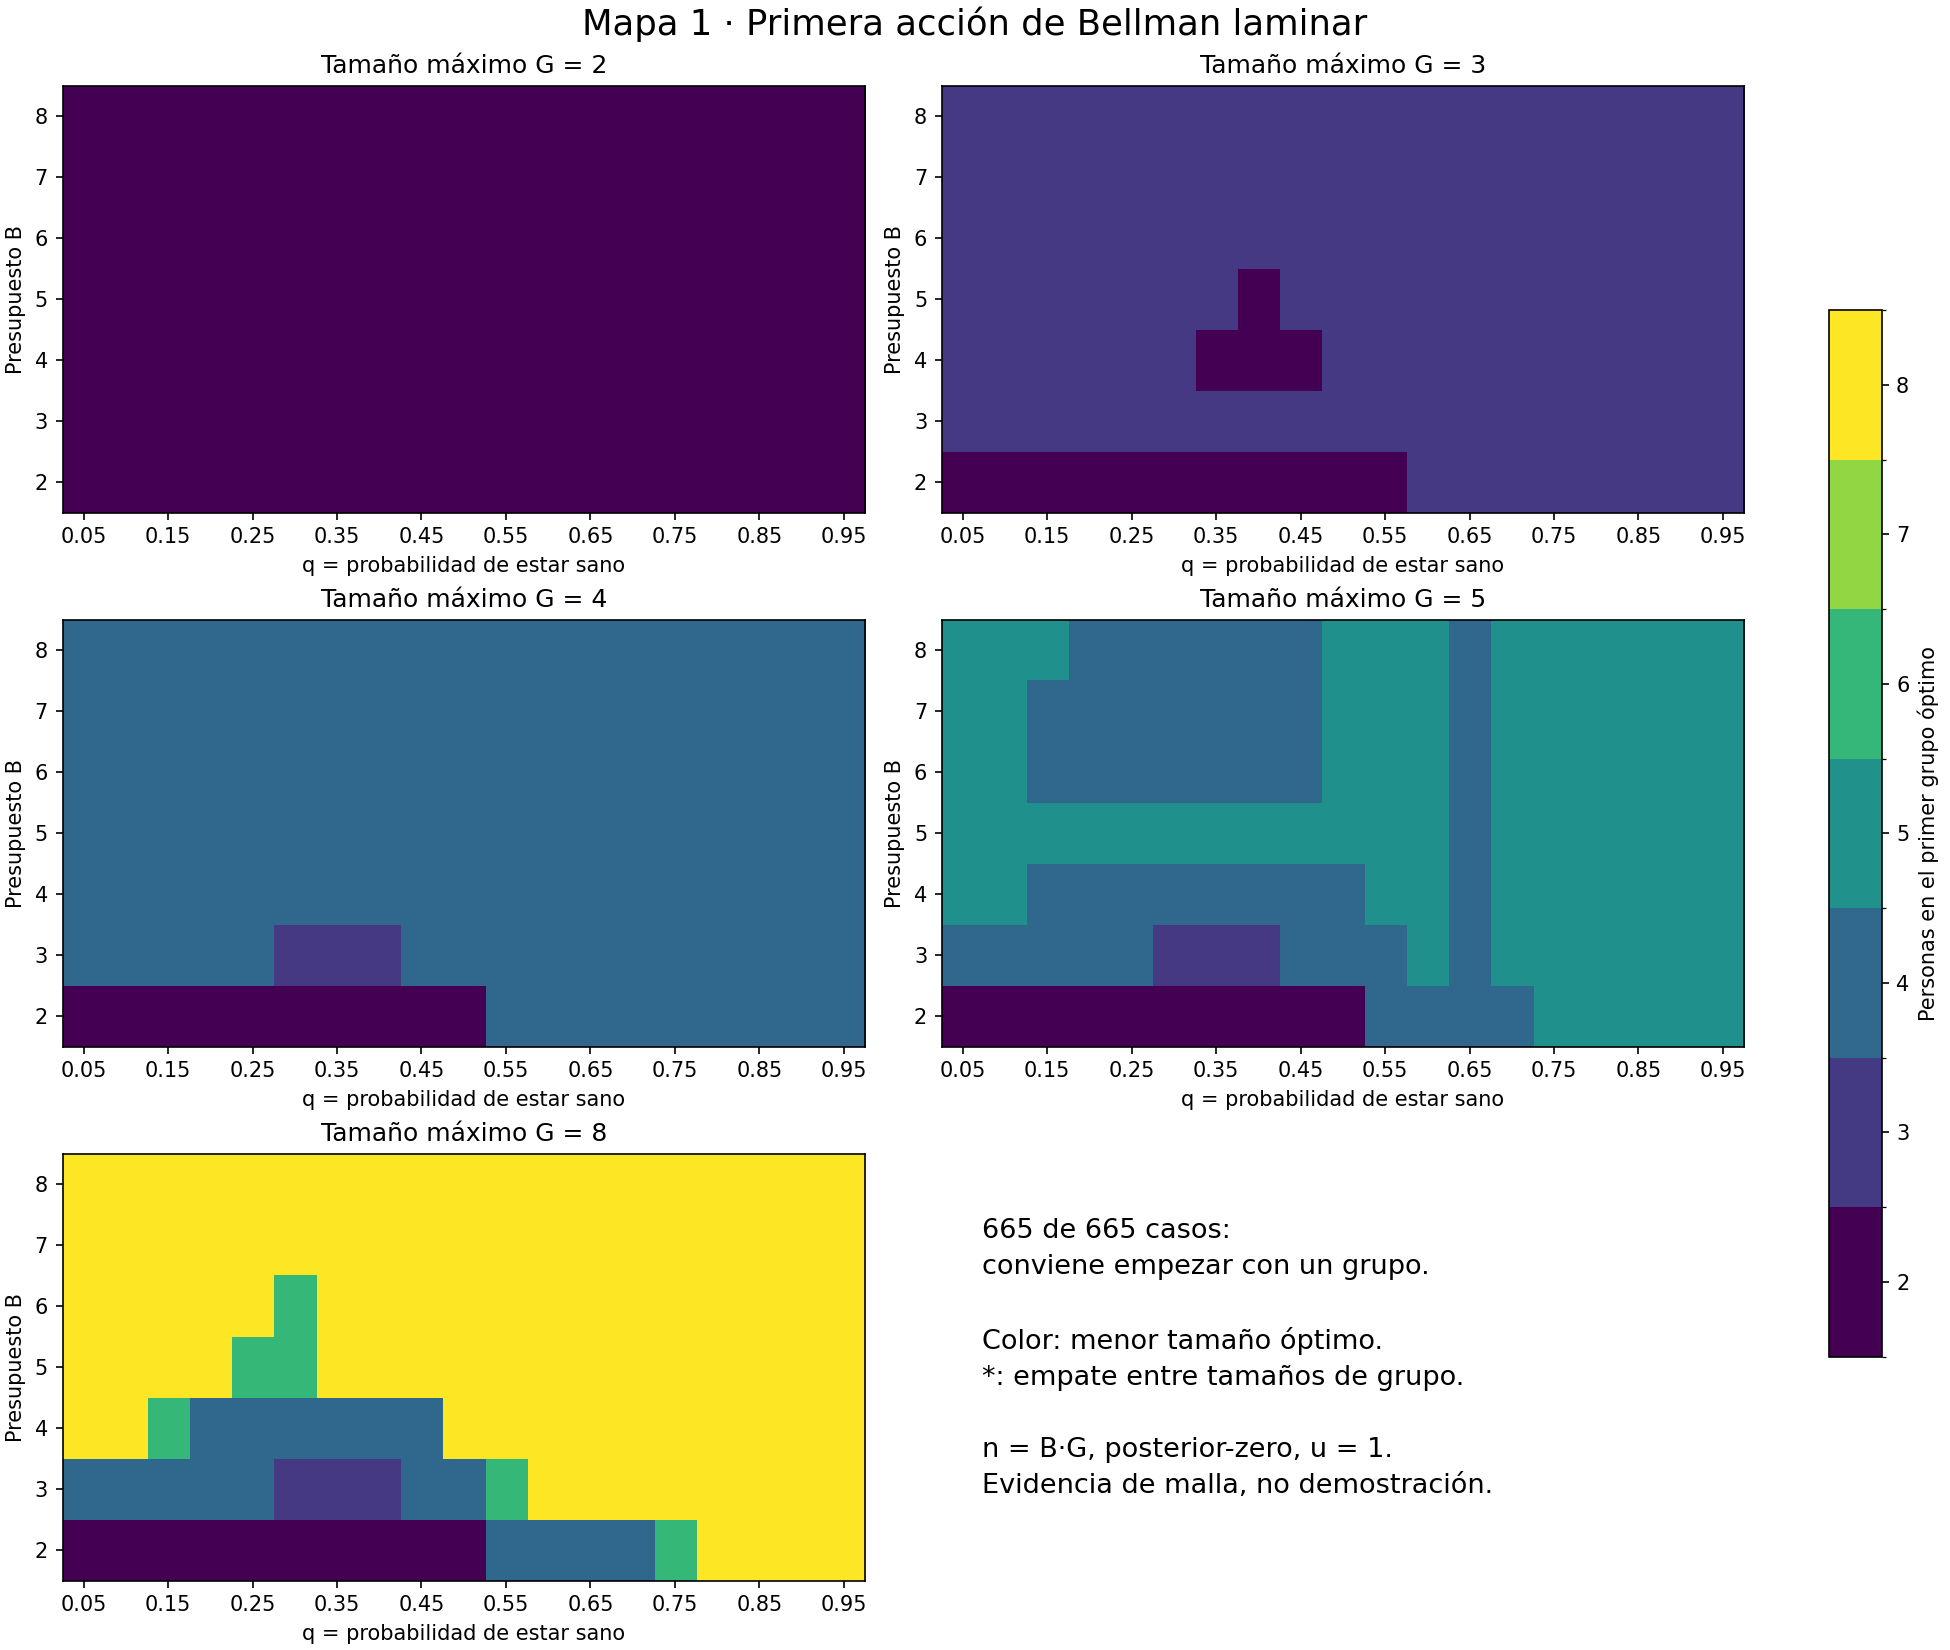

In [10]:
m3 = pd.read_csv(ROOT/'results/mapa_homogeneo_3.csv')
display(m3[['case','n','G','B','cota_cbs','cbs_stop','optimo','status']].round(6))
from IPython.display import Image
display(Image(filename=str(ROOT/'results/mapa_homogeneo_1.png')))


### Qué concluimos del Mapa 3

En la frontera: **OPT_lam=0.865394 > 0.708011**. La versión CBS que se detiene
al primer cobro vale **0.727127**, de modo que esa política explícita es subóptima.

En el ancla: permitir solamente grupos de hasta 8 ya da **1.123283**, una
política factible con el límite original G=16. Supera tanto la cota **0.914742**
como esa versión CBS (**0.939440**). El óptimo completo G=16 sigue sin calcularse.

**Para discutir:** ¿qué continuación precisa debe incluir “cover-then-bisect”
si sobran pruebas? ¿Qué hipótesis hacen demostrable la preferencia inicial por
grupos? ¿Cómo fijamos la rejilla de λ antes de una evaluación uniforme?

No confundir la garantía de encontrar al menos un sano con el número esperado
de sanos acreditados: este último puede superar uno.
